# Rank the Files Using a Flat Index
Testing for basic functionality

In [1]:
from index_FlatL2 import IndexFlatL2

In [2]:
# create a new flat index
flat = IndexFlatL2()

In [4]:
# create a faiss index from the stored embeddings
flat.create("100K_embeddings/subset_0", "test_Flat")

Index does not exist
Number of docs in .faiss file: 482414
Number of docs in .pkl file: 482414
File size: 2963951.661 KB
Time to create index: 29.0262 seconds


In [5]:
# query the results
query = "How to hike the pacific crest trail?"
flat.query(query, k = 3)

Source: 10b7c394d0517b921eee1a211208fefb913406e9.txt
Title: Cultural labor and the defetishization of environments: connecting ethnographies of tourism in Venezuela and Chile
Content: guide, a local Mapuche man, was surprised to find wired fences blocking the forest trail we were following. To facilitate our passing, he had to detach two of the wires from their supporting stakes, reattaching them as soon as we all were on the other side. As we waited for turns to go through, the guide explained that this track was clear the last time he had been there, a couple of months earlier.
Score: 0.3968276083469391
Source: 043648b61661ee5e0200b2421db69d5d684a5cee.txt
Title: 
Content: The same marked routes for Nordic walking and trail running were used for an MTB session, with a lesson on how to use a repair station and how to take advantage of the municipality's surroundings to enjoy different levels of difficulty with bicycles.
Signposting and poster examples from the routes and activities can

In [7]:
query = "How to hike the pacific crest trail?"
query_embedding = flat.embed_text(query)
query_results = flat.query_embedding(query_embedding, k=5)
query_results

{'Content': [{'Source': '10b7c394d0517b921eee1a211208fefb913406e9.txt',
   'Title': 'Title: Cultural labor and the defetishization of environments: connecting ethnographies of tourism in Venezuela and Chile',
   'Content': 'guide, a local Mapuche man, was surprised to find wired fences blocking the forest trail we were following. To facilitate our passing, he had to detach two of the wires from their supporting stakes, reattaching them as soon as we all were on the other side. As we waited for turns to go through, the guide explained that this track was clear the last time he had been there, a couple of months earlier.',
   'Score': 0.3968276},
  {'Source': '043648b61661ee5e0200b2421db69d5d684a5cee.txt',
   'Title': 'Title: ',
   'Content': "The same marked routes for Nordic walking and trail running were used for an MTB session, with a lesson on how to use a repair station and how to take advantage of the municipality's surroundings to enjoy different levels of difficulty with bicycle

# Compare the IVF Flat to the Flat Index

In [8]:
from index_IVFFlat import IndexIVFFlat

In [10]:
ivf_flat = IndexIVFFlat()
# create a faiss index from the stored embeddings
ivf_flat.create("100K_embeddings/subset_0", "test_IVFFlat")

Index does not exist
Number of docs in .faiss file: 482414
Number of docs in .pkl file: 482414
File size: 2968204.795 KB
Time to create index: 33.0636 seconds


In [12]:
# query the results
query = "How to hike the pacific crest trail?"
ivf_flat.query(query, k = 3)

Source: 0351b5c565cd691ac8176d77d28a23f61138927a.txt
Title: Field Test of a Passive Infrared Camera for Measuring Trail-Based Physical Activity
Content: Data were collected from November 19, 2016 to June 30, 2017 at the main entrance of a hiking trail accessing the West Virginia University (WVU) Falling Run Greenspace/Organic Farm, a 60-acre wooded park in Morgantown, West Virginia, USA (Figure 1 ). This trail is designed for foot traffic only; bicycles are not allowed but were observed occasionally in the present study. Preliminary instrument set up and mounting angle tests were conducted prior to full data collection to ascertain that photos captured bi-directional walking and jogging along the trail concurrently with infrared sensor timestamps. The PIC was cable-locked within a metal security box, mounted to a 10-cm diameter grapevine 3 m from the edge of a 0.6-m wide hiking trail. The camera had an unobstructed view perpendicular to the trail from the uphill slope at roughly 1.8 m 

# Test Evaluating the Accuracy

Create indexes

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from index_FlatL2 import IndexFlatL2
from index_IVFFlat import IndexIVFFlat
from index_PQ import IndexPQ

In [3]:
flat = IndexFlatL2()
ivf_flat = IndexIVFFlat()
pq = IndexPQ()

In [3]:
flat.create("100K_embeddings/subset_0", "indexes/flat")
ivf_flat.create("100K_embeddings/subset_0", "indexes/ivf_flat")
pq.create("100K_embeddings/subset_0", "indexes/pq")

Index does not exist
Number of docs in .faiss file: 482414
Number of docs in .pkl file: 482414
File size: 2963951.661 KB
Time to create index: 25.1728 seconds
Index does not exist
Number of docs in .faiss file: 482414
Number of docs in .pkl file: 482414
File size: 2968204.795 KB
Time to create index: 26.5064 seconds
Index does not exist
Number of docs in .faiss file: 482414
Number of docs in .pkl file: 482414
File size: 5432.262 KB
Time to create index: 52.1344 seconds


If index is already created then read from it here

In [4]:
flat.read("indexes/flat")
ivf_flat.read("indexes/ivf_flat")
pq.read("indexes/pq")

Create a test set of queries

In [38]:
N_QUERIES = 100
K = 5
test_embeddings = np.load("100K_embeddings/subset_7/embeddings.npy")
# shuffle the dataset
np.random.shuffle(test_embeddings)
test_embeddings = test_embeddings[:N_QUERIES,:]
# get the test reults
flat_results = []
ivf_flat_results = []
pq_results = []
for i in range(N_QUERIES):
    flat_results.append(flat.query_embedding(test_embeddings[i,:][np.newaxis,:], K))
    ivf_flat_results.append(ivf_flat.query_embedding(test_embeddings[i,:][np.newaxis,:], K))
    pq_results.append(pq.query_embedding(test_embeddings[i,:][np.newaxis,:], K))

In [21]:
# record the amount of time taken
flat_times = [x['Time'] for x in flat_results]
ivf_flat_times = [x['Time'] for x in ivf_flat_results]
pq_times = [x['Time'] for x in pq_results]

# record the costs of the flat index
flat_costs = np.array([np.sum([x['Score'] for x in query['Content']]) for query in flat_results])

# record the costs of the other indexes
def get_cost(query_emb, query_result):
    cost = [np.sum((query_emb - flat.embed_text(x['Content']))**2) for x in query_result['Content']]
    return np.sum(cost)

ivf_flat_costs = np.array([get_cost(test_embeddings[i], ivf_flat_results[i]) for i in range(N_QUERIES)])
pq_costs = np.array([get_cost(test_embeddings[i], pq_results[i]) for i in range(N_QUERIES)])

In [23]:
flat_score = 0
ivf_flat_score = np.sum(ivf_flat_costs - flat_costs) / N_QUERIES
pq_score = np.sum(pq_costs - flat_costs) / N_QUERIES

print(f"Flat score is {flat_score}")
print(f"IVF Flat score is {ivf_flat_score}")
print(f"PQ score is {pq_score}")

Flat score is 0
IVF Flat score is 0.06748229527694188
PQ score is 0.485819924599608


# Test Benchmarks

In [39]:
# random file
all_embeddings = np.load("100K_embeddings/subset_0/embeddings.npy")
np.random.randint(0,len(all_embeddings))

random_costs = np.array([np.sum([np.sum((all_embeddings[np.random.randint(0, len(all_embeddings))] - test_embeddings[i])**2) for _ in range(K)]) for i in range(N_QUERIES)])
random_score = np.sum(random_costs - flat_costs) / N_QUERIES
print(f"Random file comparison score is {random_score}")

Random file comparison score is 1.5965663817703126


# Evaluate Performance for Different Model Sizes

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from index_FlatL2 import IndexFlatL2
from index_IVFFlat import IndexIVFFlat
from index_PQ import IndexPQ

In [ ]:
flat = IndexFlatL2()
ivf_flat = IndexIVFFlat()
pq = IndexPQ()

In [ ]:
# define the test set
test_embeddings = np.load("100K_embeddings/subset_7/embeddings.npy")
# shuffle the dataset
np.random.shuffle(test_embeddings)
test_embeddings = test_embeddings[:N_QUERIES,:]

In [46]:
N_QUERIES = 100
K = 5
NUM_BATCHES = 5

"""Compute the sum of distances between the query and the top K search results for an index"""
def get_cost(query_emb, query_result):
    cost = [np.sum((query_emb - flat.embed_text(x['Content']))**2) for x in query_result['Content']]
    return np.sum(cost)

# define variables to hold the data
flat_times = []
ivf_flat_times = []
pq_times = []
flat_scores = []
ivf_flat_scores = []
pq_scores = []
random_scores = []

for batch_num in range(NUM_BATCHES):
    # add more files to each index
    flat.create(f"100K_embeddings/subset_{batch_num}", "indexes/flat")
    ivf_flat.create(f"100K_embeddings/subset_{batch_num}", "indexes/ivf_flat")
    pq.create(f"100K_embeddings/subset_{batch_num}", "indexes/pq")
    if batch_num == 0:
        all_embeddings = np.load("100K_embeddings/subset_0/embeddings.npy")
    else:
        all_embeddings = np.vstack((all_embeddings, np.load(f"100K_embeddings/subset_{batch_num}/embeddings.npy")))

    # get the results
    flat_results = [flat.query_embedding(test_embeddings[i,:][np.newaxis,:], K) for i in range(N_QUERIES)]
    ivf_flat_results = [ivf_flat.query_embedding(test_embeddings[i,:][np.newaxis,:], K) for i in range(N_QUERIES)]
    pq_results = [pq.query_embedding(test_embeddings[i,:][np.newaxis,:], K) for i in range(N_QUERIES)]

    # record the amount of time taken
    flat_times.append(np.mean([x['Time'] for x in flat_results]))
    ivf_flat_times.append(np.mean([x['Time'] for x in ivf_flat_results]))
    pq_times.append(np.mean([x['Time'] for x in pq_results]))

    # record the costs of the flat index
    flat_costs = np.array([np.sum([x['Score'] for x in query['Content']]) for query in flat_results])
    ivf_flat_costs = np.array([get_cost(test_embeddings[i], ivf_flat_results[i]) for i in range(N_QUERIES)])
    pq_costs = np.array([get_cost(test_embeddings[i], pq_results[i]) for i in range(N_QUERIES)])
    random_costs = np.array([np.sum([np.sum((all_embeddings[np.random.randint(0, len(all_embeddings))] - test_embeddings[i])**2) for _ in range(K)]) for i in range(N_QUERIES)])

    # record the scores
    flat_scores.append(0)
    ivf_flat_scores.append(np.mean(ivf_flat_costs - flat_costs))
    pq_scores.append(np.mean(pq_costs - flat_costs))
    random_scores.append(np.mean(random_costs - flat_costs))

    # print the scores and the times
    print(f"Flat score is {flat_scores[batch_num]}")
    print(f"IVF Flat score is {ivf_flat_scores[batch_num]}")
    print(f"PQ score is {pq_scores[batch_num]}")
    print(f"Random score is {random_scores[batch_num]}")
    print('')
    print(f"Flat time is {flat_times[batch_num]}")
    print(f"IVF Flat time is {ivf_flat_times[batch_num]}")
    print(f"PQ time is {pq_times[batch_num]}")

Index does not exist
Number of docs in .faiss file: 482414
Number of docs in .pkl file: 482414
File size: 2963951.661 KB
Time to create index: 20.8678 seconds
Index does not exist
Number of docs in .faiss file: 482414
Number of docs in .pkl file: 482414
File size: 2968204.795 KB
Time to create index: 20.7784 seconds
Index does not exist
Number of docs in .faiss file: 482414
Number of docs in .pkl file: 482414
File size: 5432.262 KB
Time to create index: 31.4048 seconds
Flat score is 0
IVF Flat score is 0.07439315857831601
PQ score is 0.512692888722732
Random score is 1.540677274926273

Flat time is 0.17283944368362428
IVF Flat time is 0.003270587921142578
PQ time is 0.001666090488433838
Index exists
Number of docs in .faiss file: 987616
Number of docs in .pkl file: 987616
File size: 6067912.749 KB
Time to create index: 43.2628 seconds
Index exists
Number of docs in .faiss file: 987616
Number of docs in .pkl file: 987616
File size: 6076207.499 KB
Time to create index: 67.5268 seconds
In

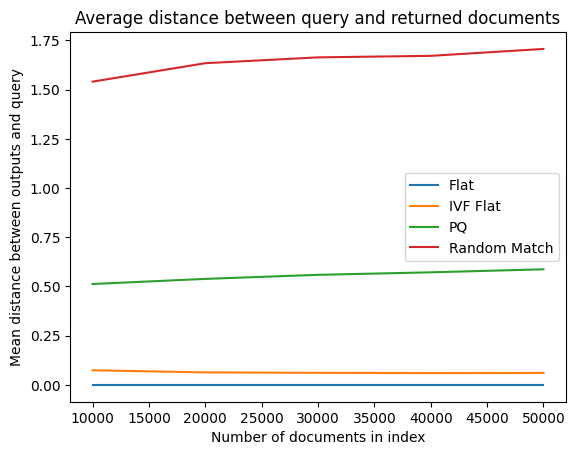

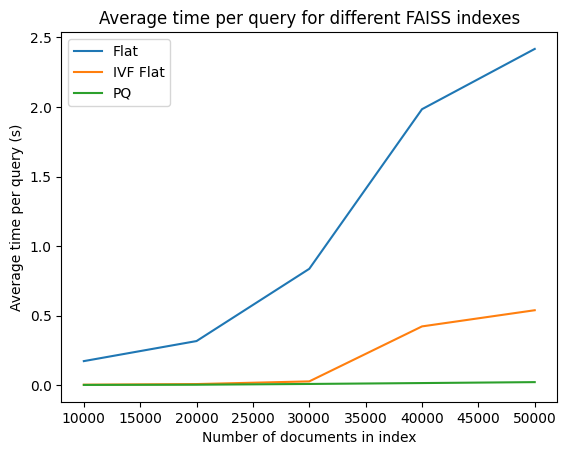

In [53]:
num_documents = np.array(range(1,NUM_BATCHES+1))*10000
plt.plot(num_documents, flat_scores, label='Flat')
plt.plot(num_documents, ivf_flat_scores, label='IVF Flat')
plt.plot(num_documents, pq_scores, label='PQ')
plt.plot(num_documents, random_scores, label='Random Match')
plt.title("Average distance between query and returned documents")
plt.xlabel("Number of documents in index")
plt.ylabel("Mean distance between outputs and query")
plt.legend()
plt.show()

plt.plot(num_documents, flat_times, label='Flat')
plt.plot(num_documents, ivf_flat_times, label='IVF Flat')
plt.plot(num_documents, pq_times, label='PQ')
plt.title("Average time per query for different FAISS indexes")
plt.xlabel("Number of documents in index")
plt.ylabel("Average time per query (s)")
plt.legend()
plt.show()